In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [3]:
import torch
import numpy as np
import panel as pn
from IPython.display import display, clear_output
pn.extension()
import matplotlib.pyplot as plt


In [4]:
from polarizedpotentialparticles.configs import Config, ParticleConfig, SimulationConfig, LossConfig
from polarizedpotentialparticles.trainer import Trainer
from polarizedpotentialparticles.displays import Displayer

In [5]:
p_cfg = ParticleConfig()
t_cfg = SimulationConfig()
l_config = LossConfig()

l_config.target = "circle"

cfg = Config(particle_config=p_cfg, simulation_config=t_cfg, loss_config=l_config)

trainer = Trainer(cfg)
displayer = Displayer(trainer)

In [6]:
# check if it is running on gpu
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {cfg.device}")

Using device: cuda


# Todo
Symmetrize

~~N_nbs~~

Normalize different inputs

In [7]:
# pretrain

steps = 10

for ep in range(100):
    print(ep,"/", "100", end="\r")
    trainer.train(steps, accumulate_loss=True, step_loss=True)


clear_output(wait=True)
rollout = trainer.rollout(steps = 3*steps)

to_display = []
to_display.append(displayer.display_loss())
# to_display.append(displayer.display_rollout_as_static(rollout))
to_display.append(displayer.display_rollout_image(rollout))
to_display.append(displayer.display_rollout_image_gauss(rollout))
to_display.append(displayer.display_rollout_image_gauss_difference(rollout))
# to_display.append(displayer.display_rollout_3d(rollout))

display(displayer.display_multiple(to_display))


BokehModel(combine_events=True, render_bundle={'docs_json': {'f5e8c69f-e5a6-4b7c-8f08-a55f7b39cc46': {'version…

In [ ]:
steps = 225

every = int(2000/steps)


d = 25

for ep in range(20000):
    print(ep,"/", "20000", end="\r")
    rnd = np.random.randint(-d, d) if d > 0 else 0
    trainer.train(steps + rnd, accumulate_loss=True, step_loss=True)

    if (ep+1) % 50 == 0:
        clear_output(wait=True)
        rollout = trainer.rollout(steps = steps + d)

        to_display = []
        to_display.append(displayer.display_loss())
        # to_display.append(displayer.display_rollout_as_static(rollout))
        to_display.append(displayer.display_rollout_image(rollout))
        to_display.append(displayer.display_rollout_image_gauss(rollout))
        to_display.append(displayer.display_rollout_image_gauss_difference(rollout))
        # to_display.append(displayer.display_rollout_3d(rollout))

        display(displayer.display_multiple(to_display))


BokehModel(combine_events=True, render_bundle={'docs_json': {'3469768e-c718-4eb8-abba-74ff1581c8a9': {'version…

In [1]:
# save the model
trainer.save_model("model2.pt")

NameError: name 'trainer' is not defined

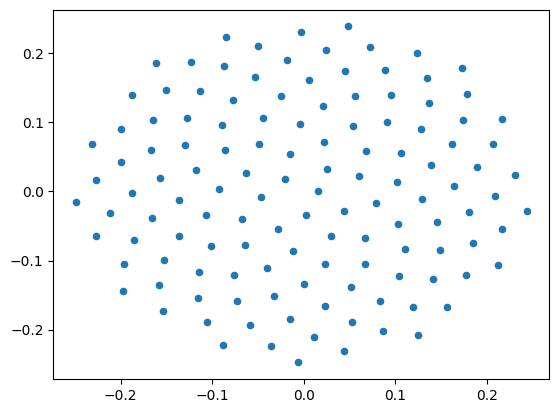

In [ ]:
x, y, a ,b = rollout[0].T

plt.scatter(x, y, s=20)

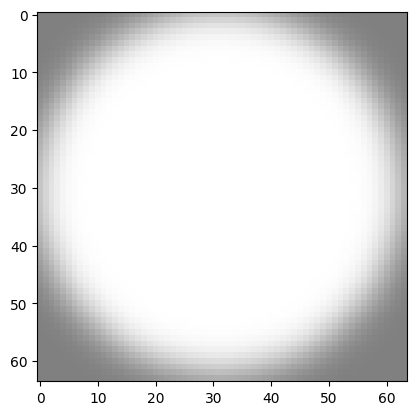

In [ ]:
plt.imshow(img_grid.cpu().numpy(), cmap='gray', alpha=0.5)

In [ ]:
# see all trainable parameters
for name, param in trainer.particle_system.named_parameters():
    if param.requires_grad:
        print(name,)

message_conv.nn.0.weight
message_conv.nn.0.bias
message_conv.nn.2.weight
message_conv.nn.2.bias
message_conv.lin.0.weight
message_conv.lin.0.bias
message_conv.lin.2.weight
message_conv.lin.2.bias
message_to_output_layer.weight
message_to_output_layer.bias
